In [47]:
from torchvision import datasets,transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import numpy as np
from torchvision.transforms import v2

In [48]:
transform = v2.Compose([
    v2.Resize((32, 32)),
    v2.ToTensor(),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [49]:
train_data = datasets.GTSRB(root='../data', split='train', download=True, transform=transform)
test_data = datasets.GTSRB(root='../data', split='test', download=True, transform=transform)

print(f'Training samples: {len(train_data)}')
print(f'Test samples: {len(test_data)}')

Training samples: 26640
Test samples: 12630


[ 150 1500 1500  960 1320 1260  300  960  960  990 1350  900 1410 1440
  540  420  300  750  810  150  240  240  270  360  180 1020  420  180
  360  180  300  540  180  480  300  810  270  150 1380  210  240  180
  180]


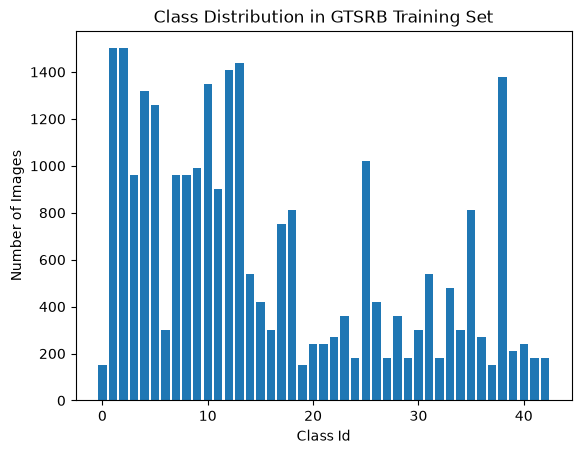

In [50]:
labels = [label for _, label in train_data._samples]
counts = np.bincount(labels)
print(counts)

plt.bar(range(len(counts)), counts)
plt.xlabel('Class Id')
plt.ylabel('Number of Images')
plt.title('Class Distribution in GTSRB Training Set')
plt.show()


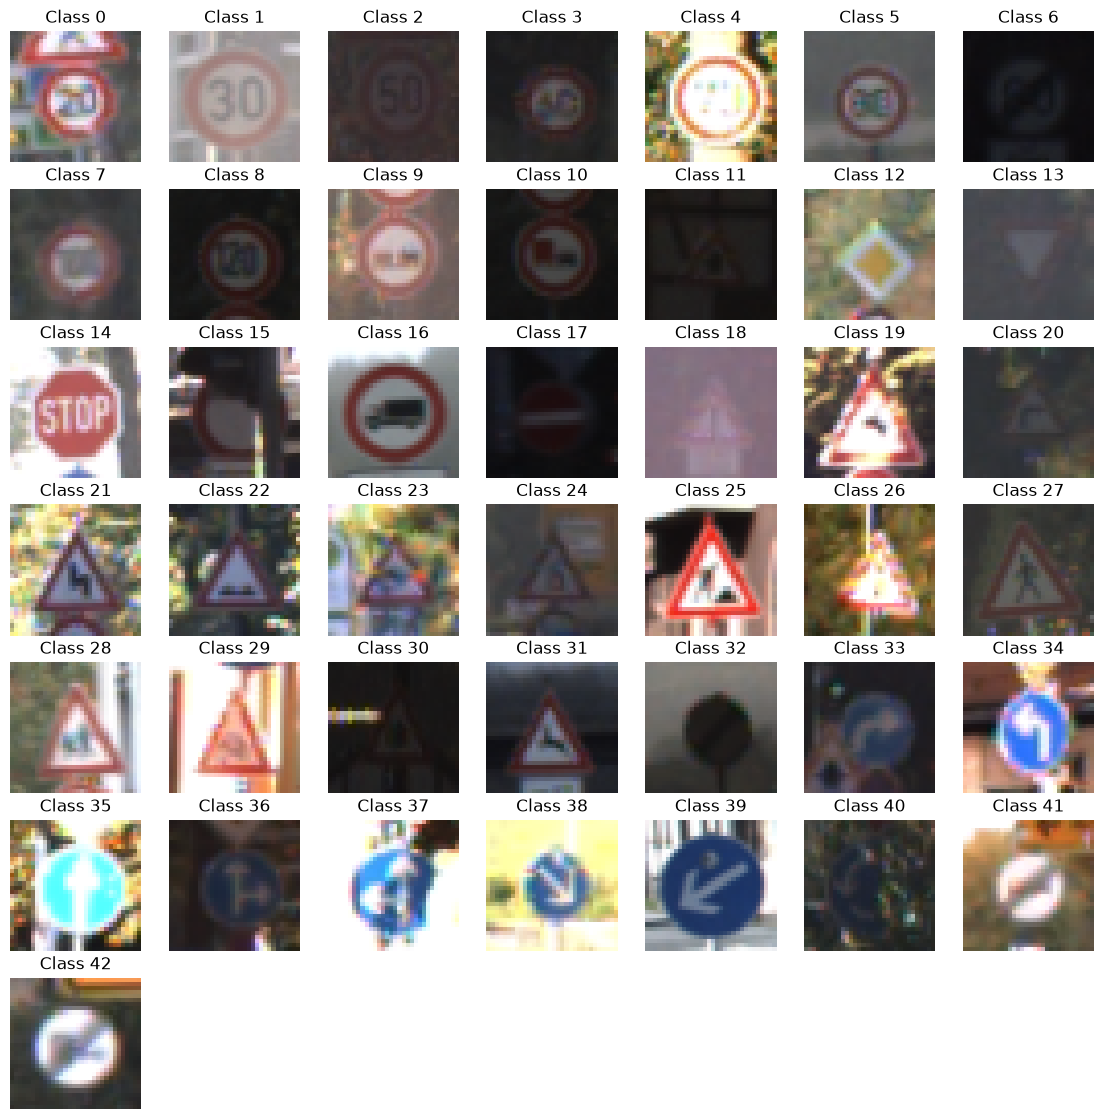

In [51]:
first_idx = [labels.index(i) for i in range(len(counts))]
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(7, 7, figsize=(14, 14))
for i in range(len(counts)):
    image, label = train_data[first_idx[i]]
    image = image * std + mean
    ax = axes[i // 7, i % 7]
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(f'Class {label}')
    ax.axis('off')

for i in range(len(counts), 49):
    ax = axes[i // 7, i % 7]
    ax.axis('off')


In [52]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

image, label = next(iter(train_loader))
print(image.shape)
print(label.shape)

torch.Size([64, 3, 32, 32])
torch.Size([64])


In [ ]:
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(3072, 128)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(128, 43)

    def forward(self, x):
        # Defines the path data takes through the network
        x = self.flatten(x)
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x